# Подготовка данных

**Виды**

Машинное обчение можно разделить на несколько больших категорий:

*Обучение с учителем*

Обучение с учителем (или управляемое обучение). Здесь данные представлены вместе с дополнительными признаками, которые мы хотим предсказать. Это может быть любая из следующих задач:
1. классификация: выборки данных принадлежат к двум или более классам и мы хотим научиться на уже размеченных данных предсказывать класс неразмеченной выборки. Примером задачи классификации может стать распознавание рукописных чисел, цель которого — присвоить каждому входному набору данных одну из конечного числа дискретных категорий. Другой способ понимания классификации — это понимание ее в качестве дискретной (как противоположность непрерывной) формы управляемого обучения, где у нас есть ограниченное количество категорий, предоставленных для N выборок; и мы пытаемся их пометить правильной категорией или классом.
2. регрессионный анализ: если желаемый выходной результат состоит из одного или более непрерывных переменных, тогда мы сталкиваемся с регрессионным анализом. Примером решения такой задачи может служить предсказание длинны лосося как результата функции от его возраста и веса.


*Обучение без учителя*

Обучение без учителя (или самообучение). В данном случае обучающая выборка состоит из набора входных данных Х без каких-либо соответствующих им значений. Целью подобных задач может быть определение групп схожих элементов внутри данных. Это называется кластеризацией или кластерным анализом. Также задачей может быть установление распределения данных внутри пространства входов, называемое густотой ожидания (density estimation). Или это может быть выделение данных из высоко размерного пространства в двумерное или трехмерное с целью визуализации данных.

**Обучающая выборка и контрольная выборка**

Машинное обучение представляет собой обучение выделению некоторых свойств выборки данных и применение их к новым данным. Вот почему общепринятая практика оценки алгоритма в Машинном обучении — это разбиение данных вручную на два набора данных. Первый из них — это обучающая выборка, на ней изучаются свойства данных. Второй — контрольная выборка, на ней тестируются эти свойства.




# Пример: анализ выборки

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://stepik.org/media/attachments/course/57984/titanic.csv', index_col=0)

In [3]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

<b>Survived</b> - Выжил (0 = No, 1 = Yes) <br>
<b>Pclass</b>  - Класс билета (1 = 1st, 2 = 2nd, 3 = 3rd)<br>
<b>Sex</b>  - Пол (male = мужчина, female = женщина)	<br>
<b>Age</b>  - Возраст в годах <br>
<b>SibSp</b>  - Кол-во сестер/братьев/жен/мужей на Титанике 	<br>
<b>Parch</b>  - Кол-во родителей/детей на Титанике	<br>
<b>Ticket</b>  - Номер билета	<br>
<b>Fare</b>  - Плата за проезд 	<br>
<b>Cabin</b>  - Номер каюты 	<br>
<b>Embarked</b>  - 	Порт погрузки (C = Cherbourg, Q = Queenstown, S = Southampton)<br>

**Анализ данных**

In [5]:
df.shape

(891, 11)

In [6]:
df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [7]:
# Статистика
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Посмотрим, кого больше на борту: женщин или мужчин?

In [8]:
import seaborn as sns

<Axes: xlabel='Sex', ylabel='count'>

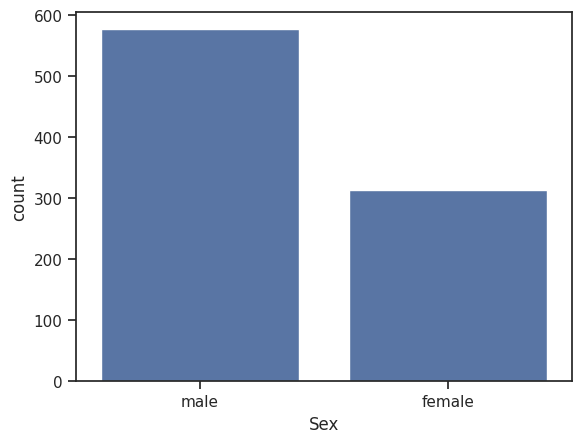

In [10]:
sns.set(style="ticks")
sns.countplot(x='Sex', data=df)

Разделим эту статистику по классам

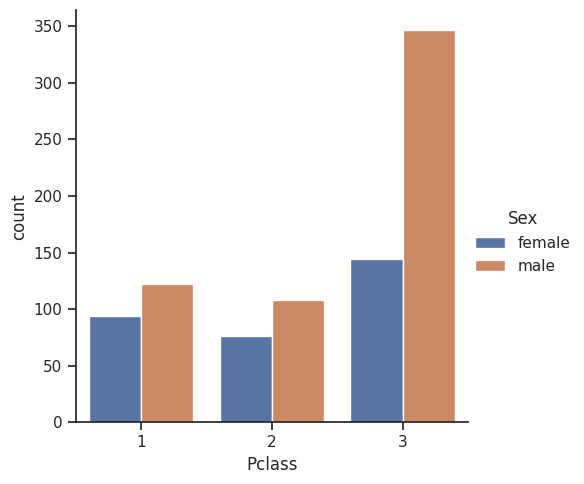

In [13]:
sns.catplot(x='Pclass', data=df, hue='Sex', kind='count')

Узнаем сколько детей путешествовало на титанике

In [14]:
df['Person'] = df.Sex
df.loc[df['Age'] < 16, 'Person'] = 'Child'

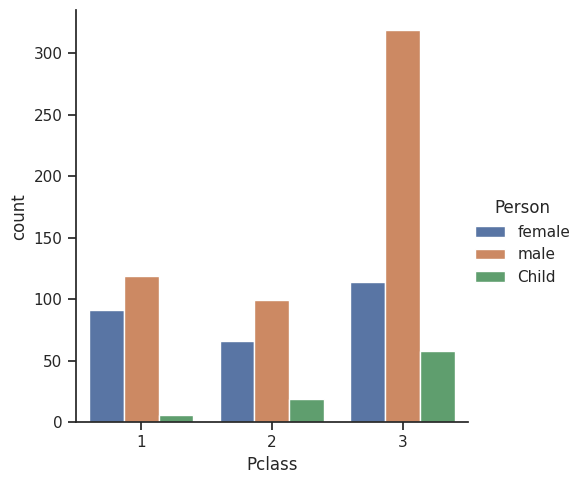

In [16]:
sns.catplot(x='Pclass', data=df, hue='Person', kind='count')

Изобразим распределение по возрастам

<Axes: >

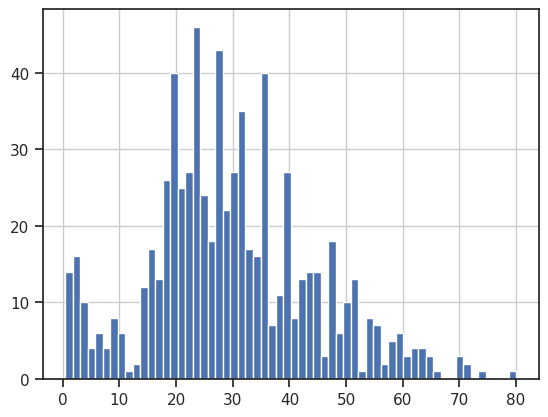

In [17]:
df.Age.hist(bins=60)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


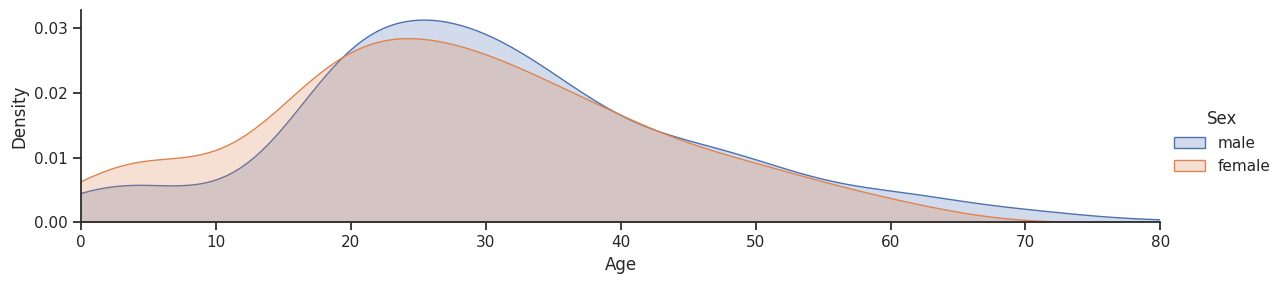

In [18]:
# Еще один способ визуализировать данные - FacetGrid

fig = sns.FacetGrid(df, hue="Sex", aspect=4)
fig.map(sns.kdeplot, 'Age', shade=True)

fig.set(xlim=(0, df['Age'].max()))

fig.add_legend()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


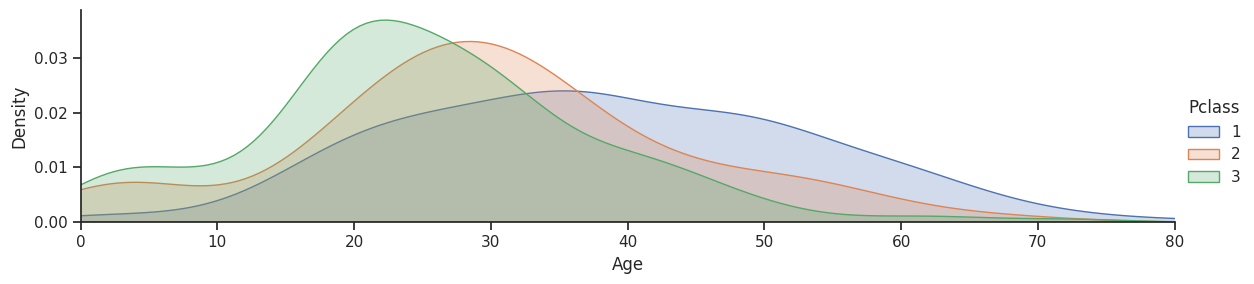

In [19]:
# Тоже самое с классом билета

fig = sns.FacetGrid(df, hue="Pclass",aspect=4)
fig.map(sns.kdeplot, 'Age', shade=True)

fig.set(xlim=(0, df['Age'].max()))

fig.add_legend()

In [20]:
df.sort_values(by='Ticket').head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person
PassengerId,,,,,,,,,,,,
505,1,1,"Maioni, Miss. Roberta",female,16.0,0,0,110152,86.50,B79,S,female
258,1,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.50,B77,S,female
760,1,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,0,0,110152,86.50,B77,S,female
263,0,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.65,E67,S,male
559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.65,E67,S,female


Билеты имеют какой-то странный формат<br>
Видно, что по одному номеру билета путешествовало сразу несколько людей, причем часто — с разными фамилиями

In [21]:
df.Cabin[df.Cabin.notna()].unique()

array(['C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6', 'C23 C25 C27',
       'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33', 'F G73', 'E31',
       'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101', 'F E69', 'D47',
       'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4', 'A32', 'B4',
       'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35', 'C87', 'B77',
       'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19', 'B49', 'D',
       'C22 C26', 'C106', 'C65', 'E36', 'C54', 'B57 B59 B63 B66', 'C7',
       'E34', 'C32', 'B18', 'C124', 'C91', 'E40', 'T', 'C128', 'D37',
       'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44', 'A34', 'C104',
       'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14', 'B37', 'C30',
       'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38', 'B39', 'B22',
       'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68', 'B41', 'A20',
       'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48', 'E58', 'C126',
       'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63', 'C62 C64',
       'E24

In [22]:
df[df.Cabin.isin(['C23 C25 C27','B96 B98'])]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person
PassengerId,,,,,,,,,,,,
28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0,C23 C25 C27,S,male
89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0,C23 C25 C27,S,female
342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0,C23 C25 C27,S,female
391,1,1,"Carter, Mr. William Ernest",male,36.0,1,2,113760,120.0,B96 B98,S,male
436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.0,B96 B98,S,Child
439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0,C23 C25 C27,S,male
764,1,1,"Carter, Mrs. William Ernest (Lucile Polk)",female,36.0,1,2,113760,120.0,B96 B98,S,female
803,1,1,"Carter, Master. William Thornton II",male,11.0,1,2,113760,120.0,B96 B98,S,Child


Номера кают прописаны мало у когo<br>
В существующих номерах кают прописан код палубы

/tmp/ipykernel_14028/4123649590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cabin', data=cabin_df, palette='winter_d')


<Axes: xlabel='Cabin', ylabel='count'>

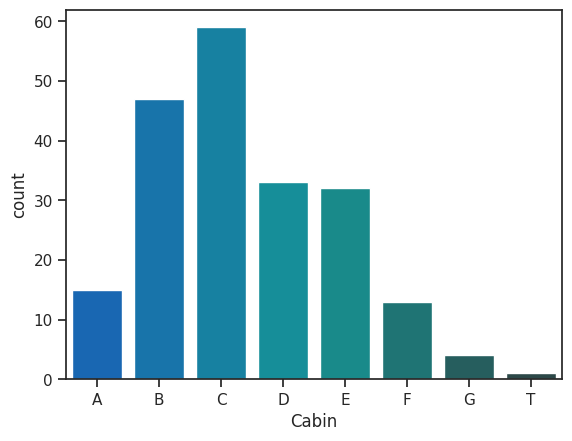

In [25]:
levels = []
for level in df['Cabin'].dropna():
    levels.append(level[0])

cabin_df = pd.DataFrame(levels)
cabin_df.columns = ['Cabin']
cabin_df.sort_values(by='Cabin', inplace=True)
sns.countplot(x='Cabin', data=cabin_df, palette='winter_d')

/tmp/ipykernel_14028/1307784754.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cabin', data=cabin_df, palette='summer_d')


<Axes: xlabel='Cabin', ylabel='count'>

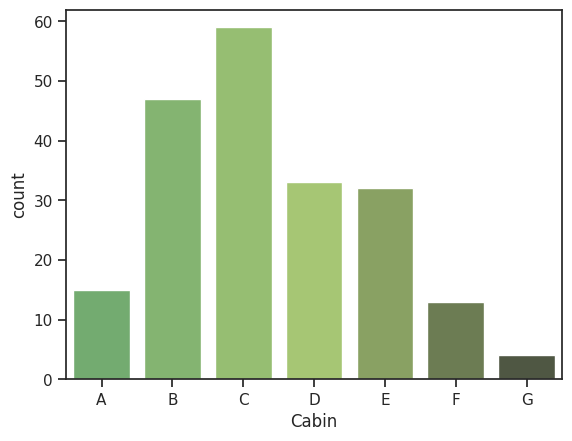

In [27]:
cabin_df = cabin_df[cabin_df.Cabin != 'T']
sns.countplot(x='Cabin', data=cabin_df, palette='summer_d')

In [28]:
import matplotlib.pyplot as plt

<Axes: xlabel='Embarked', ylabel='count'>

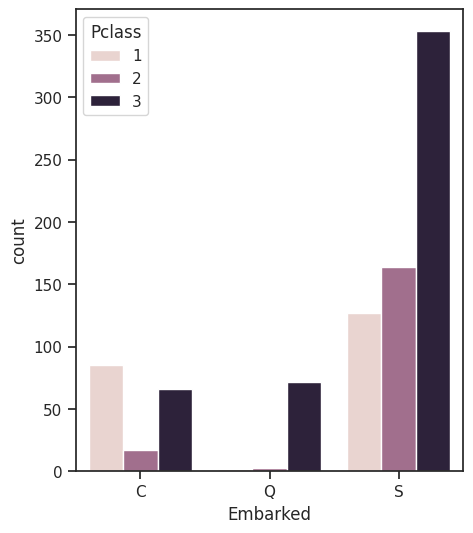

In [30]:
plt.figure(figsize=(5, 6))
sns.countplot(x='Embarked', data=df, hue='Pclass', order=['C', 'Q', 'S'])

In [66]:
df.sort_values(by='Name').head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare,Salutation
PassengerId,,,,,,,,,,,,,,,,
846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.55,NA,S,male,0,True,Low,Mr
747,0,3,"Abbott, Mr. Rossmore Edward",male,16.0,1,1,C.A. 2673,20.25,NA,S,male,2,False,High_Mid,Mr
280,1,3,"Abbott, Mrs. Stanton (Rosa Hunt)",female,35.0,1,1,C.A. 2673,20.25,NA,S,female,2,False,High_Mid,Mrs
309,0,2,"Abelson, Mr. Samuel",male,30.0,1,0,P/PP 3381,24.00,NA,C,male,1,False,High_Mid,Mr
875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.00,NA,C,female,1,False,High_Mid,Mrs


Отсортировав по имени, получаем, что многие путешествовали семьями, часто семьи оказались разделены, выжила лишь часть

In [31]:
df['Family'] = df.Parch + df.SibSp

In [32]:
df['Is_Alone'] = df.Family == 0

<Axes: xlabel='Is_Alone', ylabel='count'>

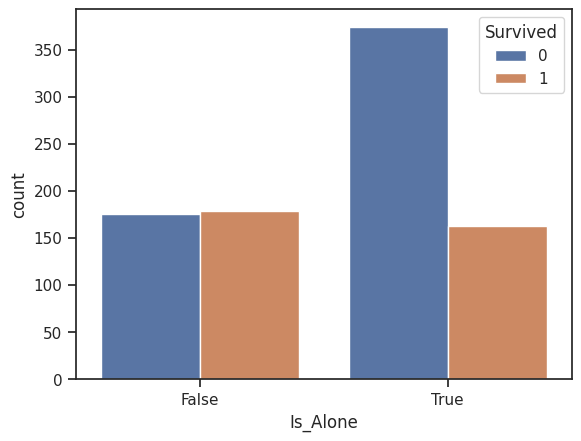

In [34]:
sns.countplot(x='Is_Alone', hue='Survived', data=df)

In [35]:
df.describe()['Fare']

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [36]:
import numpy as np

In [37]:
bins = [-1]
bins = np.append(bins, df.describe()['Fare'][4:-1].values)
bins = np.append(bins, df['Fare'].max())
bins

array([ -1.    ,   7.9104,  14.4542,  31.    , 512.3292])

In [38]:
df['Category_fare'] = pd.cut(df['Fare'], bins=bins, labels=['Low', 'Mid', 'High_Mid', 'High'])

In [39]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,1,False,Low
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,1,False,High
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,0,True,Mid
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,1,False,High
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,0,True,Mid


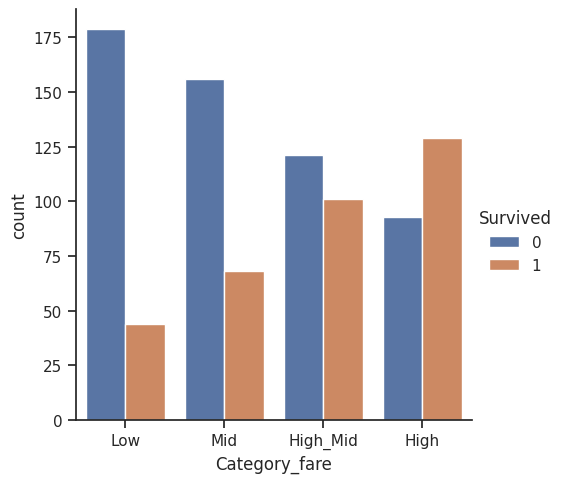

In [41]:
sns.catplot(x='Category_fare', hue='Survived', data=df, kind='count')

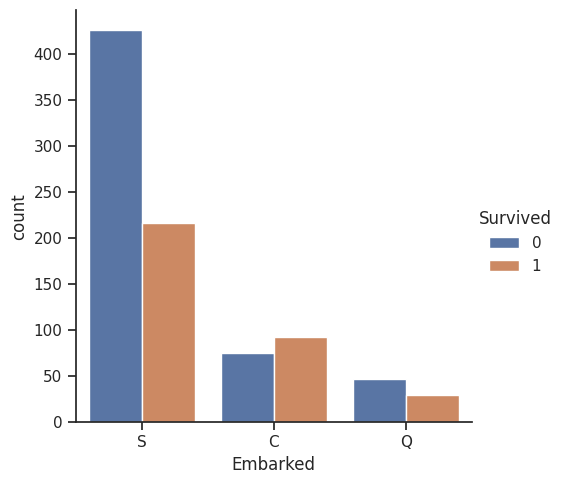

In [43]:
sns.catplot(x='Embarked', hue='Survived', data=df, kind='count')

# Пример: подготовка данных



Обработка пропущенных значений

In [44]:
# Количество строк с пропущенными значениями
df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


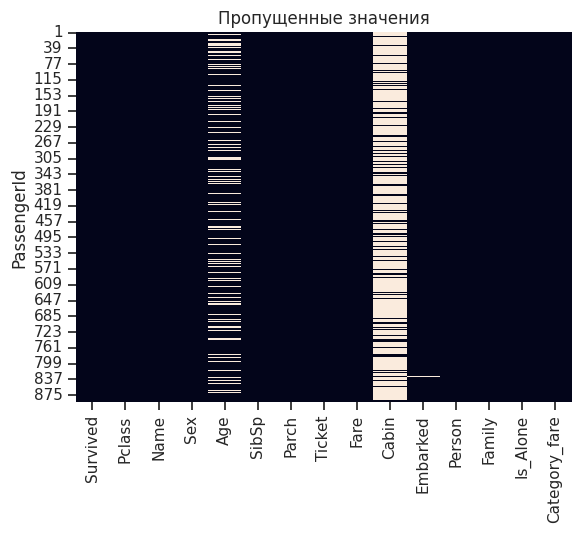

In [45]:
sns.heatmap(df.isnull(), cbar = False).set_title("Пропущенные значения");

In [46]:
df.Embarked.mode()

,Embarked
0,S


Заполним нулями пропущенные значения

In [47]:
df.Embarked.fillna(df.Embarked.mode()[0], inplace = True)

/tmp/ipykernel_14028/2669875352.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Embarked.fillna(df.Embarked.mode()[0], inplace = True)


In [48]:
df.Cabin = df.Cabin.fillna('NA')

In [49]:
df['Salutation'] = df.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

In [50]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare,Salutation
PassengerId,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NA,S,male,1,False,Low,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,1,False,High,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NA,S,female,0,True,Mid,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,1,False,High,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NA,S,male,0,True,Mid,Mr


In [51]:
grp = df.groupby(['Sex', 'Pclass', 'Salutation'])
df.Age = grp.Age.apply(lambda x: x.fillna(x.median()))
# df.Age.fillna(df.Age.median, inplace = True)

/tmp/ipykernel_14028/1545334686.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.Age = grp.Age.apply(lambda x: x.fillna(x.median()))


In [52]:
grp.Age.median()

Sex     Pclass  Salutation  
female  1       Dr              49.0
                Lady            48.0
                Miss            30.0
                Mlle            24.0
                Mme             24.0
                Mrs             41.5
                the Countess    33.0
        2       Miss            24.0
                Mrs             32.0
                Ms              28.0
        3       Miss            18.0
                Mrs             31.0
male    1       Capt            70.0
                Col             58.0
                Don             40.0
                Dr              44.0
                Jonkheer        38.0
                Major           48.5
                Master           4.0
                Mr              40.0
                Sir             49.0
        2       Dr              38.5
                Master           1.0
                Mr              31.0
                Rev             46.5
        3       Master           4.0
                Mr              26.0
Name: Age, dtype: float64

In [53]:
df.loc[[1, 878, 879, 889]]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare,Salutation
PassengerId,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NA,S,male,1,False,Low,Mr
878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NA,S,male,0,True,Low,Mr
879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NA,S,male,0,True,Low,Mr
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NA,S,female,3,False,High_Mid,Miss


In [54]:
Y = df['Survived']
X = df[df.columns[1:]]

In [55]:
X['Deck'] = X.Cabin.str[0]

In [56]:
X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare,Salutation,Deck
PassengerId,,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NA,S,male,1,False,Low,Mr,N
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,1,False,High,Mrs,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NA,S,female,0,True,Mid,Miss,N
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,1,False,High,Mrs,C
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NA,S,male,0,True,Mid,Mr,N


Переведем поля Sex, Embarked, Cabin в числа

In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])

In [58]:
le.classes_

array(['female', 'male'], dtype=object)

In [59]:
X['Cabin'] = LabelEncoder().fit_transform(X['Cabin'])
X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])

In [60]:
X.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare,Salutation,Deck
PassengerId,,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,146,2,male,1,False,Low,Mr,N
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,81,0,female,1,False,High,Mrs,C
3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,146,2,female,0,True,Mid,Miss,N
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,55,2,female,1,False,High,Mrs,C
5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,146,2,male,0,True,Mid,Mr,N


In [61]:
pd.get_dummies(X.Category_fare, prefix="Fare").head()

,Fare_Low,Fare_Mid,Fare_High_Mid,Fare_High
PassengerId,,,,
1,True,False,False,False
2,False,False,False,True
3,False,True,False,False
4,False,False,False,True
5,False,True,False,False


In [62]:
pd.concat([X, pd.get_dummies(X.Category_fare, prefix="Fare")], axis=1).head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Person,Family,Is_Alone,Category_fare,Salutation,Deck,Fare_Low,Fare_Mid,Fare_High_Mid,Fare_High
PassengerId,,,,,,,,,,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,146,2,male,1,False,Low,Mr,N,True,False,False,False
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,81,0,female,1,False,High,Mrs,C,False,False,False,True
3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,146,2,female,0,True,Mid,Miss,N,False,True,False,False
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,55,2,female,1,False,High,Mrs,C,False,False,False,True
5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,146,2,male,0,True,Mid,Mr,N,False,True,False,False


In [63]:
X.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked', 'Person', 'Family', 'Is_Alone', 'Category_fare',
       'Salutation', 'Deck'],
      dtype='object')

Будем использовать только значимые поля

In [64]:
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']

In [65]:
# Разделяем выборку на обучающую и тестовую

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X[cols], Y, test_size=0.2, random_state=0)

print(X_train.shape, X_test.shape)

(712, 8) (179, 8)
